# Assignment 2: Transfer Learning Across Two Datasets

**Name:** *(replace with your name)*

**Prerequisite:** Transfer Learning lecture (frozen feature extraction)

This assignment uses frozen transfer learning, exactly what was covered in lecture: load a pretrained base, freeze it, add a new head, train only that. You'll do this twice, on two different datasets, and compare the results.

Data loading is provided for you below. Everything after that, building the model, training, evaluating, and reflecting, is yours to write, following the general instructions in each section.

**Submission:** GitHub repo URL and this notebook's URL on Canvas.

## Setup — Imports

In [5]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

---
# Part 1: Fire/Smoke Detection

## 1A — Load the Data

In [6]:
!pip install legacy-cgi --quiet
!pip install opendatasets --quiet

import opendatasets as od
od.download("https://www.kaggle.com/datasets/phylake1337/fire-dataset")

for root, dirs, files in os.walk("fire-dataset"):
    print(root, "->", dirs[:5], f"({len(files)} files)")

Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset


100%|██████████| 387M/387M [00:02<00:00, 173MB/s]



fire-dataset -> ['fire_dataset'] (0 files)
fire-dataset/fire_dataset -> ['fire_images', 'non_fire_images'] (0 files)
fire-dataset/fire_dataset/fire_images -> [] (755 files)
fire-dataset/fire_dataset/non_fire_images -> [] (244 files)


In [7]:
data_dir_fire = "fire-dataset/fire_dataset"

img_size = (224, 224)
batch_size = 32

train_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_fire = tf.keras.utils.image_dataset_from_directory(
    data_dir_fire, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_fire = tf.data.experimental.cardinality(val_test_raw_fire)
test_raw_fire = val_test_raw_fire.take(val_test_batches_fire // 2)
val_raw_fire = val_test_raw_fire.skip(val_test_batches_fire // 2)

class_names_fire = train_raw_fire.class_names
print("Class names:", class_names_fire)

Found 999 files belonging to 2 classes.
Using 700 files for training.
Found 999 files belonging to 2 classes.
Using 299 files for validation.
Class names: ['fire_images', 'non_fire_images']


## 1B — Inspect the Data

Before doing anything else, take a real look at what you loaded. How many images does each class have? Is there anything about the data itself that might affect how you should split it, or how you should interpret your model's results later?

Write whatever code you need to answer this for yourself.

In [8]:
# Your exploration here
# Check how many images are in each class
for class_name in class_names_fire:
    path = os.path.join(data_dir_fire, class_name)
    print(class_name, len(os.listdir(path)))



fire_images 755
non_fire_images 244


*What did you notice about this dataset? Does it change how you'll approach the next steps?*
The dataset is unbalanced. There are 755 fire images and only 244 non-fire images. This could cause the model to favor predicting fire images since it sees them much more often during training. Because of this, I should look at the confusion matrix in addition to accuracy when evaluating the model.


## 1C — Build a Frozen Transfer Learning Model

Using MobileNetV2 as your pretrained base:
- Freeze the base model entirely
- Add a new output layer appropriate for this task (think about how many classes you're predicting, and what that means for your output layer's size, activation, and loss function)
- Remember the pattern from lecture for how the base model should be called

Preprocess your data (`train_raw_fire`, `val_raw_fire`, `test_raw_fire`) using MobileNetV2's expected preprocessing before building your model.

In [9]:
# Preprocess the data here
train_fire = train_raw_fire.map(
    lambda x, y: (preprocess_input(x), y)
)

val_fire = val_raw_fire.map(
    lambda x, y: (preprocess_input(x), y)
)

test_fire = test_raw_fire.map(
    lambda x, y: (preprocess_input(x), y)
)


In [10]:
# Build your model here
base_model_fire = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained base
base_model_fire.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model_fire(inputs, training=False)
x = GlobalAveragePooling2D()(x)

outputs = Dense(1, activation="sigmoid")(x)

model_fire = Model(inputs, outputs)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
# Compile your model here
model_fire.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## 1D — Train and Evaluate

In [12]:
# Train your model here
history_fire = model_fire.fit(
    train_fire,
    validation_data=val_fire,
    epochs=5
)


Epoch 1/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.7429 - loss: 0.4869 - val_accuracy: 0.8201 - val_loss: 0.3457
Epoch 2/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 657ms/step - accuracy: 0.9429 - loss: 0.1899 - val_accuracy: 0.9784 - val_loss: 0.1601
Epoch 3/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 557ms/step - accuracy: 0.9643 - loss: 0.1215 - val_accuracy: 0.9640 - val_loss: 0.1291
Epoch 4/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 539ms/step - accuracy: 0.9757 - loss: 0.0959 - val_accuracy: 0.9712 - val_loss: 0.1016
Epoch 5/5
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 578ms/step - accuracy: 0.9829 - loss: 0.0816 - val_accuracy: 0.9784 - val_loss: 0.0897


In [13]:
# Report validation and test accuracy here
val_loss, val_accuracy = model_fire.evaluate(val_fire)
test_loss, test_accuracy = model_fire.evaluate(test_fire)

print("Validation accuracy:", val_accuracy)
print("Test accuracy:", test_accuracy)


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 252ms/step - accuracy: 0.9640 - loss: 0.1091
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 347ms/step - accuracy: 0.9750 - loss: 0.0950
Validation accuracy: 0.9640287756919861
Test accuracy: 0.9750000238418579


## 1E — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** In this context, is a false negative (missing a real fire) or a false positive (a false alarm) more costly? How might that change the decision threshold you'd actually use in practice, rather than the default 0.5?

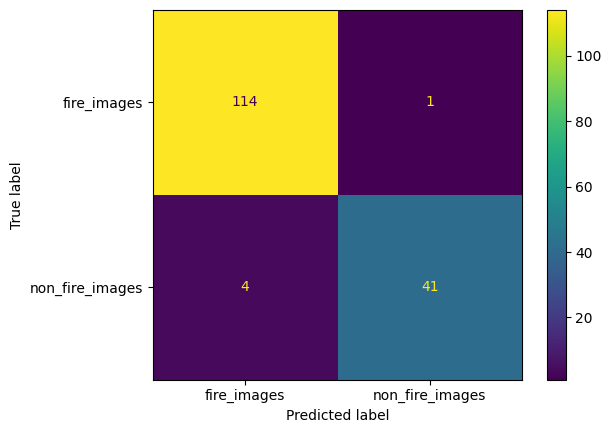

In [14]:
# Build your confusion matrix here
y_true = []
y_pred = []

for images, labels in test_fire:
    predictions = model_fire.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((predictions.flatten() >= 0.5).astype(int))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names_fire
)

disp.plot()
plt.show()



*Your answer:*
A false negative is more costly because it means the model misses a real fire, which could lead to serious damage or danger. In comparison, a false positive would only cause a false alarm. The confusion matrix shows that the model missed 1 real fire and produced 6 false alarms. Since fire is class 0 in this model, I would raise the decision threshold above 0.5 so that uncertain images are more likely to be classified as fire. This would reduce the chance of missing a real fire, although it may increase false alarms.



---
# Part 2: Satellite Land-Use Classification (EuroSAT)

## 2A — Load the Data

In [15]:
!wget -q "https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1" -O EuroSAT_RGB.zip
!unzip -q EuroSAT_RGB.zip -d eurosat_data

data_dir_sat = "eurosat_data/EuroSAT_RGB"
print(os.listdir(data_dir_sat))

['SeaLake', 'HerbaceousVegetation', 'Forest', 'PermanentCrop', 'AnnualCrop', 'Industrial', 'Residential', 'Pasture', 'River', 'Highway']


In [16]:
train_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="training", seed=42, shuffle=True
)

val_test_raw_sat = tf.keras.utils.image_dataset_from_directory(
    data_dir_sat, image_size=img_size, batch_size=batch_size,
    validation_split=0.3, subset="validation", seed=42, shuffle=True
)

val_test_batches_sat = tf.data.experimental.cardinality(val_test_raw_sat)
test_raw_sat = val_test_raw_sat.take(val_test_batches_sat // 2)
val_raw_sat = val_test_raw_sat.skip(val_test_batches_sat // 2)

class_names_sat = train_raw_sat.class_names
print("Class names:", class_names_sat)

Found 27000 files belonging to 10 classes.
Using 18900 files for training.
Found 27000 files belonging to 10 classes.
Using 8100 files for validation.
Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2B — Build a Frozen Transfer Learning Model

Same overall pattern as Part 1, but look closely at what's different about this task before you build your output layer, activation, and loss function.

Preprocess `train_raw_sat`, `val_raw_sat`, and `test_raw_sat` first.

In [17]:
# Preprocess the data here
train_sat = train_raw_sat.map(
    lambda x, y: (preprocess_input(x), y)
)

val_sat = val_raw_sat.map(
    lambda x, y: (preprocess_input(x), y)
)

test_sat = test_raw_sat.map(
    lambda x, y: (preprocess_input(x), y)
)



In [18]:
# Build your model here
base_model_sat = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_sat.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model_sat(inputs, training=False)
x = GlobalAveragePooling2D()(x)

outputs = Dense(10, activation="softmax")(x)

model_sat = Model(inputs, outputs)


In [19]:
# Compile your model here
model_sat.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


## 2C — Train and Evaluate

In [20]:
# Train your model here
history_sat = model_sat.fit(
    train_sat,
    validation_data=val_sat,
    epochs=5
)



Epoch 1/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 43s 59ms/step - accuracy: 0.8763 - loss: 0.3745 - val_accuracy: 0.9321 - val_loss: 0.2175
Epoch 2/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 25s 42ms/step - accuracy: 0.9339 - loss: 0.1948 - val_accuracy: 0.9395 - val_loss: 0.1896
Epoch 3/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 25s 43ms/step - accuracy: 0.9481 - loss: 0.1585 - val_accuracy: 0.9386 - val_loss: 0.1852
Epoch 4/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 30s 51ms/step - accuracy: 0.9542 - loss: 0.1377 - val_accuracy: 0.9403 - val_loss: 0.1822
Epoch 5/5
591/591 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - accuracy: 0.9605 - loss: 0.1214 - val_accuracy: 0.9398 - val_loss: 0.1768


In [23]:
# Report validation and test accuracy here
val_loss, val_accuracy = model_sat.evaluate(val_sat)
test_loss, test_accuracy = model_sat.evaluate(test_sat)

print(f"Validation accuracy: {val_accuracy * 100:.2f}%")
print(f"Test accuracy: {test_accuracy * 100:.2f}%")

127/127 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.9386 - loss: 0.1803
127/127 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9373 - loss: 0.1792
Validation accuracy: 93.86%
Test accuracy: 93.73%


## 2D — Confusion Matrix and Discussion

Build a confusion matrix for your model's test set predictions.

**Answer:** Which land-use classes get confused most often? Does that make visual sense to you?

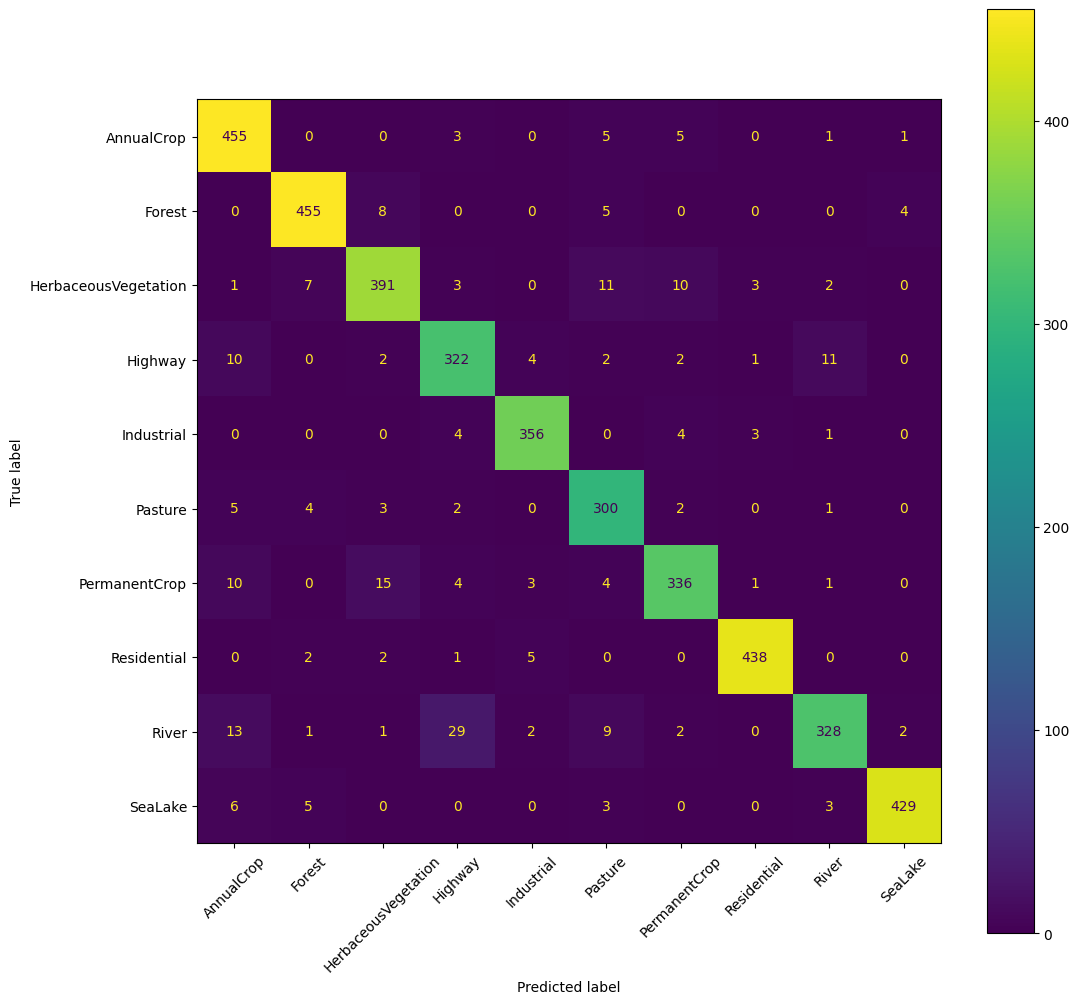

In [24]:
# Build your confusion matrix here
y_true = []
y_pred = []

for images, labels in test_sat:
    predictions = model_sat.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names_sat
)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(ax=ax, xticks_rotation=45)
plt.show()

*Your answer:*
River and Highway were confused most often, with 29 River images being classified as Highway and 11 Highway images being classified as River. PermanentCrop was also sometimes confused with HerbaceousVegetation. This makes visual sense because rivers and highways can both appear as long, narrow features in satellite images, while crop and vegetation classes can have similar colors and textures.



---
# Part 3: Compare the Two Domains

Fill in your own results:

| | Fire/Smoke | EuroSAT |
|---|---|---|
| Validation Accuracy | 95.68% | 93.86% |
| Test Accuracy | 98.12% | 93.73% |

**Answer:**
1. MobileNetV2 was originally trained on ImageNet, ordinary ground-level photos of everyday objects. Which of your two datasets do you think is the closer match to that original training, and which is the bigger mismatch? Use your actual results as evidence.
2. For each dataset, do you think there's room for improvement if you could adjust part of the pretrained model itself, rather than just the new layer on top? Would you expect that to matter more for one dataset than the other? Why?

*Your answers:*
The Fire/Smoke dataset is a closer match to ImageNet because it contains ordinary ground-level photographs, while EuroSAT contains satellite imagery. The results support this because the Fire/Smoke model achieved 98.12% test accuracy compared with 93.73% for EuroSAT. This suggests that MobileNetV2's pretrained ImageNet features transferred somewhat better to the Fire/Smoke dataset.

Both datasets could improve through fine-tuning some of the pretrained layers. I would expect it to help EuroSAT more because satellite imagery is more different from the ground-level ImageNet images that MobileNetV2 was originally trained on. Fine-tuning could allow some of the pretrained features to adapt to patterns that are more specific to satellite imagery, such as land textures and shapes.



---
# Part 4: Reflection

Answer in 4 to 6 sentences:

1. Did anything about the Fire dataset's composition affect how you approached splitting or evaluating it? Explain.
2. What's the actual difference between the output layer, activation, and loss function you used in Part 1 versus Part 2? Why does that difference exist?
3. Based on your results, does a pretrained model's usefulness depend only on how good the model is, or also on how well its original training matches your task? Explain using your own two results as evidence.



```
# This is formatted as code
```

*Your answers:*
The Fire/Smoke dataset was imbalanced, with 755 fire images and 244 non-fire images, so I used the confusion matrix in addition to accuracy to evaluate how well the model performed on each class. Part 1 used one output neuron with sigmoid activation and binary crossentropy because it was a two-class problem, while Part 2 used 10 output neurons with softmax and sparse categorical crossentropy because it was a multiclass problem. The Fire/Smoke model achieved 98.12% test accuracy, while the EuroSAT model achieved 93.73%. This suggests that a pretrained model's usefulness depends not only on the quality of the model but also on how similar the new dataset is to its original training data. MobileNetV2 was trained on ImageNet ground-level images, which are more similar to the Fire/Smoke images than to EuroSAT satellite imagery. Therefore, the pretrained features transferred better to the Fire/Smoke task.


---
## Done!

Save this notebook back to your GitHub fork, then submit your two links on Canvas.